# Week 4 — Ranking vs Decisions

This notebook explores a key idea:

**The model does not directly make decisions. It produces scores.**

Those scores can be interpreted as probabilities, which rank observations by how likely they are to belong to the positive class.

This week focuses on:
- predicted probabilities
- binary predictions vs scores
- ROC curve
- Precision–Recall curve

The goal is to understand model behaviour **before** imposing a decision threshold.

In [29]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    auc
)

## Step 1 — Create an imbalanced dataset

We use a synthetic classification dataset with far fewer positive cases than negative ones.

This mirrors the kind of class imbalance seen in areas like fraud detection, anomaly detection, and some risk problems.

In [30]:

X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=5,
    n_redundant=2,
    n_clusters_per_class=1,
    weights=[0.95, 0.05],
    flip_y=0,
    random_state=42
)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Positive class count:", np.sum(y == 1))
print("Negative class count:", np.sum(y == 0))

X shape: (1000, 10)
y shape: (1000,)
Positive class count: 50
Negative class count: 950


## Step 2 — Split into training and test sets

We split the dataset so that the model is trained on one portion and evaluated on unseen data.

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train positive count:", np.sum(y_train == 1))
print("y_test positive count:", np.sum(y_test == 1))

X_train shape: (800, 10)
X_test shape: (200, 10)
y_train positive count: 40
y_test positive count: 10


## Step 3 — Train a logistic regression model

This gives us a simple baseline classifier.

At this stage, the model learns patterns from the training data.

In [32]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


## Step 4 — Generate binary predictions

These are the final class outputs after a threshold has been applied internally.

By default, logistic regression predicts class 1 when the probability is above 0.5.

In [33]:
y_pred = model.predict(X_test)

print("First 10 binary predictions:")
print(y_pred[:10])

First 10 binary predictions:
[0 0 1 0 0 0 0 0 0 0]


## Step 5 — Generate predicted probabilities

This is the key step for Week 4.

The model does not only output a final class label.
It also produces probabilities.

These probabilities act like **scores** that rank observations by likelihood of belonging to the positive class.

In [34]:
y_proba = model.predict_proba(X_test)[:, 1]

print("First 10 predicted probabilities:")
print(y_proba[:10])

First 10 predicted probabilities:
[5.12756190e-05 4.39743775e-04 9.93879967e-01 2.05604821e-03
 5.39973080e-02 2.04733326e-04 6.60829016e-04 1.36011861e-02
 1.11541118e-02 4.08812600e-03]


## Step 6 — Compare binary predictions and probability scores

Binary predictions hide detail.

Probability scores preserve more information and allow us to inspect how confident the model is.

In [35]:
print("First 10 binary predictions:")
print(y_pred[:10])

print("\nFirst 10 probability scores:")
print(np.round(y_proba[:10], 4))

First 10 binary predictions:
[0 0 1 0 0 0 0 0 0 0]

First 10 probability scores:
[1.000e-04 4.000e-04 9.939e-01 2.100e-03 5.400e-02 2.000e-04 7.000e-04
 1.360e-02 1.120e-02 4.100e-03]


## Step 7 — Basic evaluation

Before moving into ranking-based evaluation, we quickly look at standard metrics like accuracy and the confusion matrix.

This helps connect Week 4 back to earlier weeks.

In [36]:
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9950

Confusion Matrix:
[[190   0]
 [  1   9]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       190
           1       1.00      0.90      0.95        10

    accuracy                           0.99       200
   macro avg       1.00      0.95      0.97       200
weighted avg       1.00      0.99      0.99       200



## Step 8 — ROC curve

The ROC curve evaluates model behaviour across many possible thresholds.

It shows the trade-off between:
- True Positive Rate
- False Positive Rate

This allows us to evaluate the model as a ranking system, not just as a fixed decision-maker.

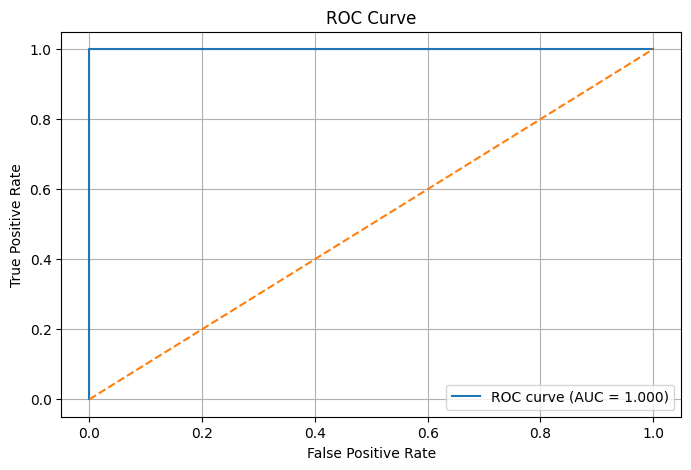

In [37]:
fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

## Step 9 — Precision–Recall curve

For imbalanced datasets, the Precision–Recall curve is often especially useful.

It shows the trade-off between:
- Precision
- Recall

This helps us understand how well the model identifies positive cases without being overwhelmed by false positives.

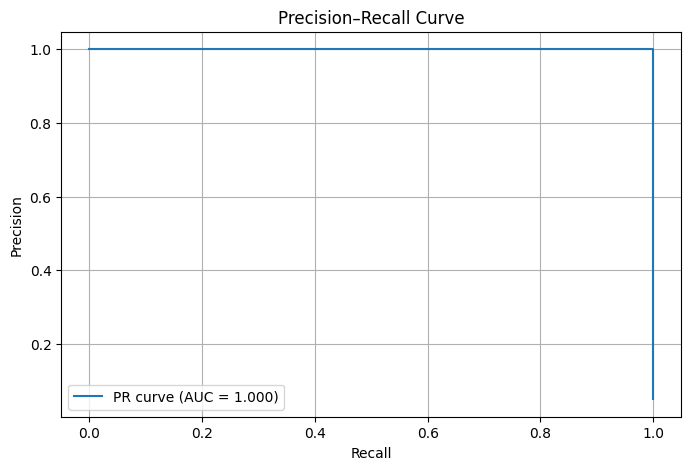

In [38]:
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, label=f"PR curve (AUC = {pr_auc:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend()
plt.grid(True)
plt.show()

## Step 10 — Inspect the highest-ranked cases

Sorting by predicted probability helps make the ranking behaviour visible.

This is closer to how many real-world systems work:
they prioritise the highest-risk or highest-likelihood cases first.

In [39]:
sorted_indices = np.argsort(y_proba)[::-1]

print("Top 10 highest probability scores and actual labels:\n")
for i in sorted_indices[:10]:
    print(f"score = {y_proba[i]:.4f}, actual = {y_test[i]}")

Top 10 highest probability scores and actual labels:

score = 0.9995, actual = 1
score = 0.9975, actual = 1
score = 0.9939, actual = 1
score = 0.9902, actual = 1
score = 0.9864, actual = 1
score = 0.9861, actual = 1
score = 0.8874, actual = 1
score = 0.8840, actual = 1
score = 0.8107, actual = 1
score = 0.4530, actual = 1


## Step 11 — Interpretation

### Key insight

The model does not directly make decisions.

It produces scores.

Those scores can then be interpreted using thresholds, score bands, or ranking-based workflows.

### Why this matters

A binary prediction answers:

> "What happens at this specific threshold?"

A probability score helps answer:

> "How strongly does the model believe this case belongs to the positive class?"

ROC and Precision–Recall curves allow us to evaluate performance across many possible thresholds.

This shifts the focus from:

> "Is the prediction correct?"

to:

> "How well does the model rank what matters?"

### Real-world framing

In systems like fraud detection, credit risk, and affordability:

- cases are often prioritised by risk
- different score bands may trigger different actions
- the threshold is a business or risk choice layered on top of the model

The model supports decisions, but it does not directly decide.

## Optional — Save the plots

This is useful if you want to use the images in GitHub, your website, or LinkedIn content.

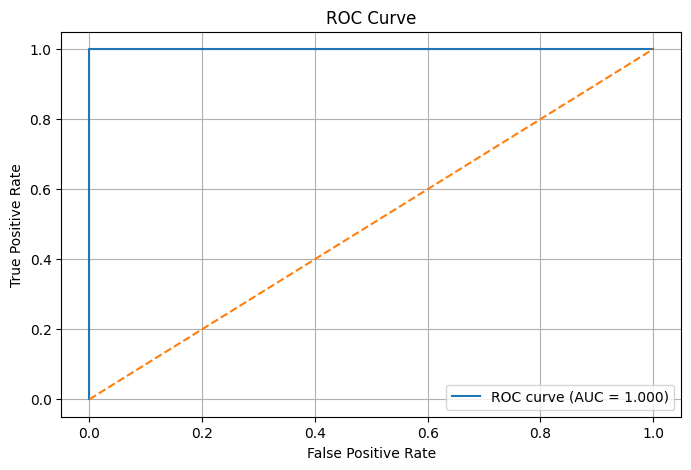

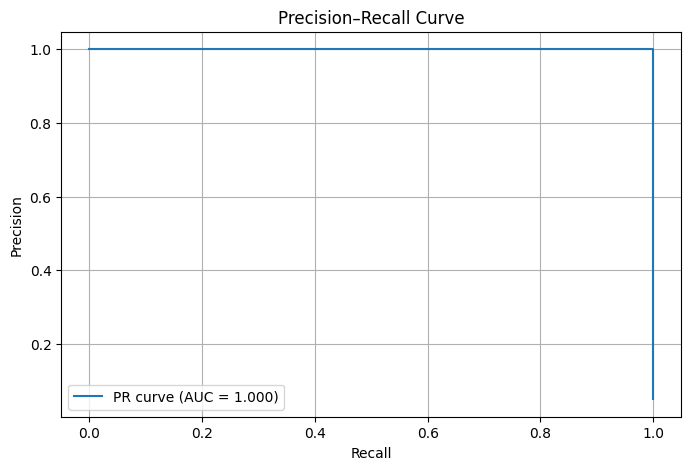

In [40]:
plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.savefig("outputs/roc-curve-week-04.png", bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, label=f"PR curve (AUC = {pr_auc:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend()
plt.grid(True)
plt.savefig("outputs/pr-curve-week-04.png", bbox_inches="tight")
plt.show()

## Week 4 conclusion

This week made one idea much clearer:

The model never actually made decisions.

It only produced scores.

The final decision only appeared when a threshold was imposed on top.

That changes how evaluation should be framed.

Rather than judging the model only at one decision point, it is often more useful to evaluate:

- how well it ranks cases
- how behaviour changes across thresholds
- how useful the score distribution is for real-world action

This creates a bridge into the next stage of evaluation:
comparing ROC-AUC and PR-AUC more explicitly, especially on imbalanced datasets.